In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Health Model

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("drive/MyDrive/health/health_data_1.csv")
df.head()

,user_id,heart_rate_BPM,blood_oxygen_level,step_count,sleep_duration_hr,activity_level,stress_level,health_score,health
0,1,65.0,98.3,5845.1,7.2,Sedentary,5,0.81320,Good
1,2,58.9,98.8,5450.4,7.2,Highly_Active,1,0.93520,Excellent
2,3,79.9,96.2,840.7,9.6,Sedentary,2,0.98480,Excellent
3,4,85.5,99.1,12448.5,7.5,Active,3,0.88765,Excellent
4,5,48.1,98.2,2244.8,5.0,Active,9,0.61030,Moderate


In [4]:
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.isnull().sum())

(9368, 9)
user_id                 int64
heart_rate_BPM        float64
blood_oxygen_level    float64
step_count            float64
sleep_duration_hr     float64
activity_level         object
stress_level            int64
health_score          float64
health                 object
dtype: object
   user_id  heart_rate_BPM  blood_oxygen_level  step_count  sleep_duration_hr  \
0        1            65.0                98.3      5845.1                7.2   
1        2            58.9                98.8      5450.4                7.2   
2        3            79.9                96.2       840.7                9.6   
3        4            85.5                99.1     12448.5                7.5   
4        5            48.1                98.2      2244.8                5.0   

  activity_level  stress_level  health_score     health  
0      Sedentary             5       0.81320       Good  
1  Highly_Active             1       0.93520  Excellent  
2      Sedentary             2       0.98480 

In [5]:
df.drop(columns=["user_id"], inplace=True)

In [6]:
from sklearn.preprocessing import LabelEncoder
le_activity = LabelEncoder()
df["activity_level"] = le_activity.fit_transform(df["activity_level"])

In [7]:
le_health = LabelEncoder()
df["health"] = le_health.fit_transform(df["health"])
print(le_health.classes_)  # See which label maps to which number

['Excellent' 'Good' 'Moderate' 'Poor']


In [8]:
X = df.drop(columns=["health"])
y = df["health"]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler_health = StandardScaler()
X_train = scaler_health.fit_transform(X_train)
X_test = scaler_health.transform(X_test)   # transform only — never fit on test data

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [12]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    accuracy_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize

In [13]:
results = {}
model = RandomForestClassifier(random_state = 42)
train_acc = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
model.fit(X_train,y_train)
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
y_train_pred = cross_val_predict(model, X_train, y_train, cv = 3)
cm = confusion_matrix(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred, average='weighted')
recall = recall_score(y_train, y_train_pred, average='weighted')
f1 = f1_score(y_train, y_train_pred, average='weighted')

In [14]:
results.update({"Random Forest": {
        "Train Accuracy": train_acc.mean(),
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }})

In [15]:
results

{'Random Forest': {'Train Accuracy': np.float64(0.9994662396583934),
  'Test Accuracy': 0.9994663820704376,
  'Precision': 0.9994668486703207,
  'Recall': 0.9994662396583934,
  'F1 Score': 0.9994641895218449}}

In [16]:
if hasattr(model, "predict_proba"):
    y_scores = model.predict_proba(X_test)
else:
    y_scores = model.decision_function(X_test)

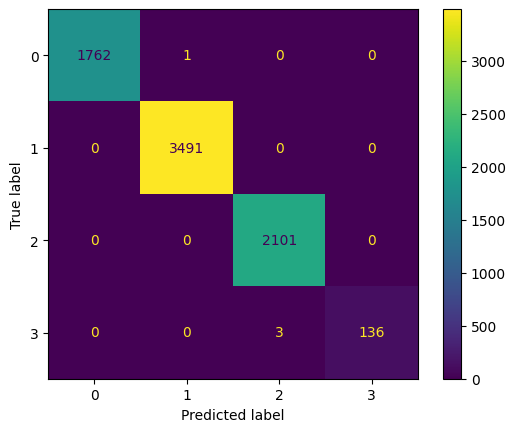

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

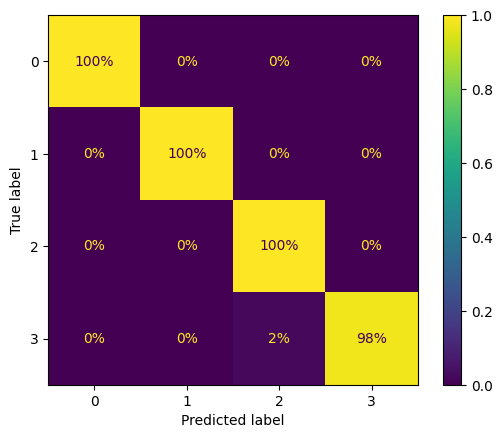

In [18]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize = "true", values_format = ".0%")
plt.show()

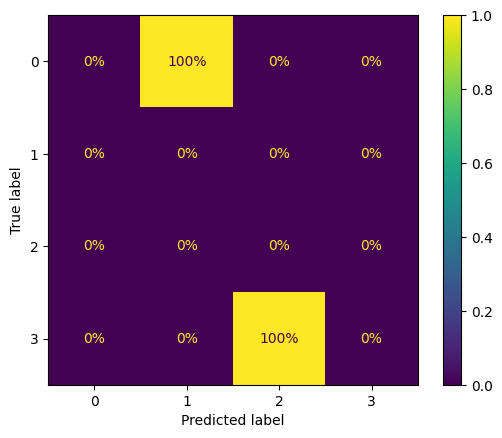

In [19]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize = "true", values_format = ".0%")
plt.show()

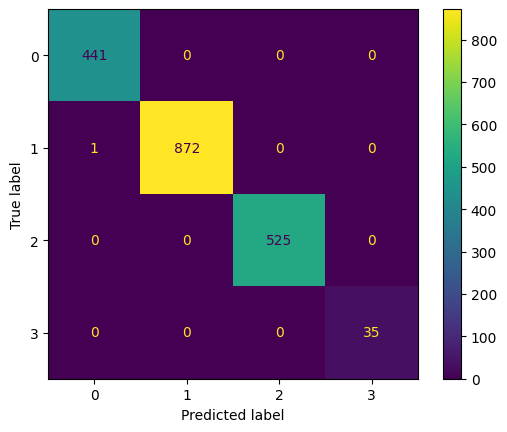

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.show()

# Stress Model

In [21]:
df2 = pd.read_csv("drive/MyDrive/health/health_data_1.csv")
df2.head()

,user_id,heart_rate_BPM,blood_oxygen_level,step_count,sleep_duration_hr,activity_level,stress_level,health_score,health
0,1,65.0,98.3,5845.1,7.2,Sedentary,5,0.81320,Good
1,2,58.9,98.8,5450.4,7.2,Highly_Active,1,0.93520,Excellent
2,3,79.9,96.2,840.7,9.6,Sedentary,2,0.98480,Excellent
3,4,85.5,99.1,12448.5,7.5,Active,3,0.88765,Excellent
4,5,48.1,98.2,2244.8,5.0,Active,9,0.61030,Moderate


In [22]:
print(df2.shape)
print(df2.dtypes)
print(df2.head())
print(df2.isnull().sum())

(9368, 9)
user_id                 int64
heart_rate_BPM        float64
blood_oxygen_level    float64
step_count            float64
sleep_duration_hr     float64
activity_level         object
stress_level            int64
health_score          float64
health                 object
dtype: object
   user_id  heart_rate_BPM  blood_oxygen_level  step_count  sleep_duration_hr  \
0        1            65.0                98.3      5845.1                7.2   
1        2            58.9                98.8      5450.4                7.2   
2        3            79.9                96.2       840.7                9.6   
3        4            85.5                99.1     12448.5                7.5   
4        5            48.1                98.2      2244.8                5.0   

  activity_level  stress_level  health_score     health  
0      Sedentary             5       0.81320       Good  
1  Highly_Active             1       0.93520  Excellent  
2      Sedentary             2       0.98480 

In [23]:
df2.drop(columns=["user_id"], inplace=True)

In [24]:
from sklearn.preprocessing import LabelEncoder
le_activity = LabelEncoder()
df2["activity_level"] = le_activity.fit_transform(df2["activity_level"])

In [25]:
le_health = LabelEncoder()
df2["health"] = le_health.fit_transform(df2["health"])
print(le_health.classes_)  # See which label maps to which number

['Excellent' 'Good' 'Moderate' 'Poor']


In [26]:
X_2 = df2.drop(columns=["health", "stress_level"])
y_2 = df2["stress_level"]

In [27]:
from sklearn.model_selection import train_test_split
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2, y_2, test_size=0.2, random_state=42, stratify=y
)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler_stress = StandardScaler()
X_train_2 = scaler_stress.fit_transform(X_train_2)
X_test_2 = scaler_stress.transform(X_test_2)   # transform only — never fit on test data

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [30]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    accuracy_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize

In [31]:
results = {}
model_2 = RandomForestClassifier(random_state = 42)
train_acc_2 = cross_val_score(model_2, X_train_2, y_train_2, cv=3, scoring="accuracy")
model_2.fit(X_train_2, y_train_2)
y_test_pred_2 = model_2.predict(X_test_2)
test_acc_2 = accuracy_score(y_test_2, y_test_pred_2)
y_train_pred_2 = cross_val_predict(model_2, X_train_2, y_train_2, cv = 3)
cm_2 = confusion_matrix(y_train_2, y_train_pred_2)
precision_2 = precision_score(y_train_2, y_train_pred_2, average='weighted')
recall_2 = recall_score(y_train_2, y_train_pred_2, average='weighted')
f1_2 = f1_score(y_train_2, y_train_pred_2, average='weighted')

In [32]:
results.update({"Random Forest": {
        "Train Accuracy": train_acc_2.mean(),
        "Test Accuracy": test_acc_2,
        "Precision": precision_2,
        "Recall": recall_2,
        "F1 Score": f1_2
    }})

In [33]:
results

{'Random Forest': {'Train Accuracy': np.float64(0.9208700293568187),
  'Test Accuracy': 0.9509071504802561,
  'Precision': 0.9209816604643996,
  'Recall': 0.9208700293568188,
  'F1 Score': 0.9207585401136003}}

In [34]:
if hasattr(model_2, "predict_proba"):
    y_scores_2 = model_2.predict_proba(X_test_2)
else:
    y_scores_2 = model_2.decision_function(X_test_2)

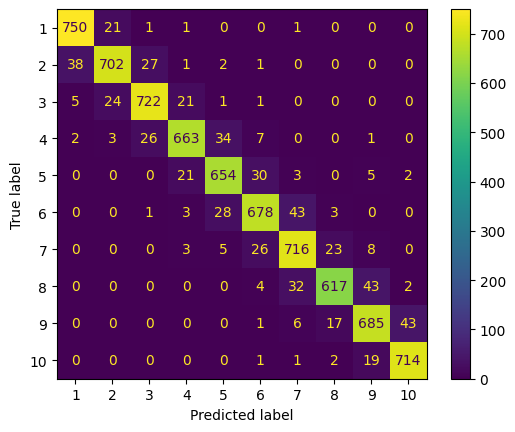

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train_2, y_train_pred_2)
plt.show()

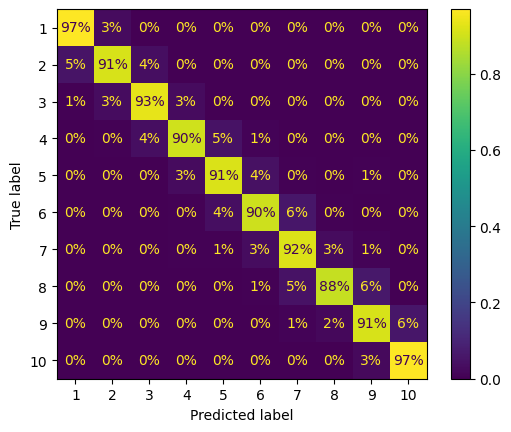

In [36]:
ConfusionMatrixDisplay.from_predictions(y_train_2, y_train_pred_2, normalize = "true", values_format = ".0%")
plt.show()

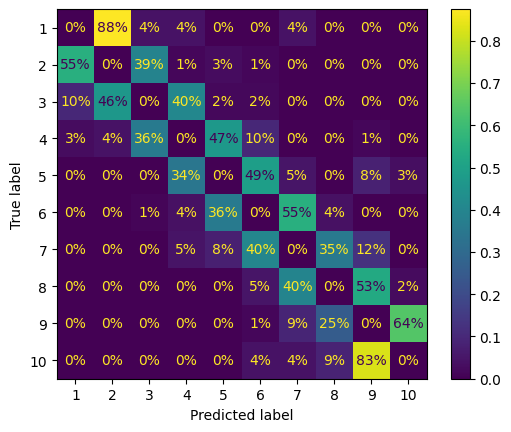

In [37]:
sample_weight = (y_train_pred_2 != y_train_2)
ConfusionMatrixDisplay.from_predictions(y_train_2, y_train_pred_2, sample_weight=sample_weight, normalize = "true", values_format = ".0%")
plt.show()

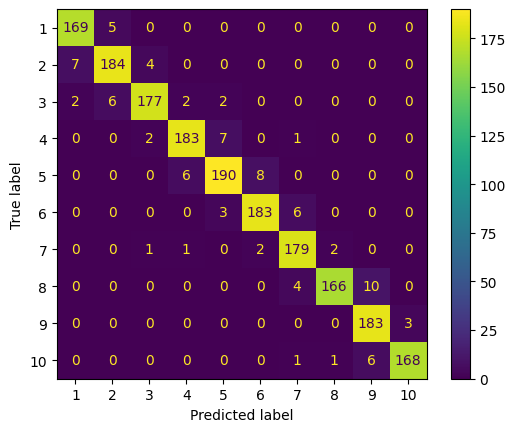

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test_2, y_test_pred_2)
plt.show()

# Chaining

In [39]:
import pandas as pd
import numpy as np

def predict_full_health_profile(heart_rate, blood_oxygen, steps, sleep, activity_str, health_score):
    # 1. Define the exact column names used during training
    # Based on image_a19c99.png and your dropping of 'user_id' and 'health'
    stress_feature_names = [
        'heart_rate_BPM', 'blood_oxygen_level', 'step_count',
        'sleep_duration_hr', 'activity_level', 'health_score'
    ]

    health_feature_names = [
        'heart_rate_BPM', 'blood_oxygen_level', 'step_count',
        'sleep_duration_hr', 'activity_level', 'stress_level', 'health_score'
    ]

    # 2. Prepare data for the Stress Model
    activity_encoded = le_activity.transform([activity_str])[0]

    stress_df = pd.DataFrame([[
        heart_rate, blood_oxygen, steps, sleep, activity_encoded, health_score
    ]], columns=stress_feature_names)

    # Scale and Predict Stress
    stress_features_scaled = scaler_stress.transform(stress_df)
    predicted_stress = model_2.predict(stress_features_scaled)[0]

    # 3. Prepare data for the Health Model
    health_df = pd.DataFrame([[
        heart_rate,          # index 0
        blood_oxygen,        # index 1
        steps,               # index 2
        sleep,               # index 3
        activity_encoded,    # index 4
        predicted_stress,    # index 5 (The Virtual Sensor)
        health_score         # index 6
    ]], columns=health_feature_names)

    # Scale and Predict Health
    health_features_scaled = scaler_health.transform(health_df)
    health_pred_encoded = model.predict(health_features_scaled)[0]
    health_category = le_health.inverse_transform([health_pred_encoded])[0]

    return {
    "Stress Level (Estimated)": int(predicted_stress), # Converts np.int64 to int
    "Health Category": health_category
}

In [42]:
result = predict_full_health_profile(66.0, 99.3, 5486.1, 7.6, "Sedentary", 0.81520)
print(result)

{'Stress Level (Estimated)': 5, 'Health Category': 'Good'}


In [51]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_chained_pipeline(X_test_df, y_test_labels):
    chained_preds = []

    # We iterate through the test set as if they are new incoming users
    for _, row in X_test_df.iterrows():
        # Simulate missing stress level by not passing it
        res = predict_full_health_profile(
            row['heart_rate_BPM'], row['blood_oxygen_level'],
            row['step_count'], row['sleep_duration_hr'],
            le_activity.inverse_transform([int(row['activity_level'])])[0],
            row['health_score']
        )
        chained_preds.append(res['Health Category'])

    # Convert labels to same format for comparison
    y_test_actual = le_health.inverse_transform(y_test_labels)

    print("--- Chained Pipeline Evaluation ---")
    print(f"Chained Accuracy: {accuracy_score(y_test_actual, chained_preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_actual, chained_preds))

# create from ORIGINAL features before scaling
X_test_df = pd.DataFrame(
    scaler_stress.inverse_transform(X_test_2),
    columns=[
        'heart_rate_BPM', 'blood_oxygen_level', 'step_count',
        'sleep_duration_hr', 'activity_level', 'health_score'
    ]
)

evaluate_chained_pipeline(X_test_df, y_test)

--- Chained Pipeline Evaluation ---
Chained Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00       441
        Good       1.00      1.00      1.00       873
    Moderate       1.00      1.00      1.00       525
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00      1874
   macro avg       1.00      1.00      1.00      1874
weighted avg       1.00      1.00      1.00      1874



In [52]:
def predict_health_with_guardrails(heart_rate, blood_oxygen, steps, sleep, activity_str, health_score):
    # --- STEP 1: INPUT VALIDATION (Clipping) ---
    # Sensors often glitch; we clip values to realistic human ranges
    hr = np.clip(heart_rate, 30, 220)
    spo2 = np.clip(blood_oxygen, 70, 100)

    # --- STEP 2: STRESS PREDICTION ---
    activity_encoded = le_activity.transform([activity_str])[0]
    stress_feat_names = ['heart_rate_BPM', 'blood_oxygen_level', 'step_count', 'sleep_duration_hr', 'activity_level', 'health_score']

    stress_df = pd.DataFrame([[hr, spo2, steps, sleep, activity_encoded, health_score]],
                             columns=stress_feat_names)

    stress_scaled = scaler_stress.transform(stress_df)

    # Check Stress Confidence
    stress_probs = model_2.predict_proba(stress_scaled)
    max_stress_conf = np.max(stress_probs)
    predicted_stress = model_2.predict(stress_scaled)[0]

    # --- STEP 3: HEALTH PREDICTION ---
    health_feat_names = ['heart_rate_BPM', 'blood_oxygen_level', 'step_count', 'sleep_duration_hr', 'activity_level', 'stress_level', 'health_score']
    health_df = pd.DataFrame([[hr, spo2, steps, sleep, activity_encoded, predicted_stress, health_score]],
                             columns=health_feat_names)

    health_scaled = scaler_health.transform(health_df)

    # Check Health Confidence
    health_probs = model.predict_proba(health_scaled)
    max_health_conf = np.max(health_probs)
    health_pred = model.predict(health_scaled)[0]
    health_label = le_health.inverse_transform([health_pred])[0]

    # --- STEP 4: RESULT LOGIC ---
    # If the model is less than 50% sure, we flag it as uncertain
    status = "Reliable" if (max_stress_conf > 0.5 and max_health_conf > 0.5) else "Uncertain"

    return {
        "Stress": int(predicted_stress),
        "Health": health_label,
        "System_Status": status,
        "Stress_Confidence": f"{max_stress_conf:.1%}",
        "Note": "Values were adjusted for sensor noise" if (hr != heart_rate or spo2 != blood_oxygen) else "Normal"
    }

# Example of a "glitchy" sensor input (250 BPM is clipped to 220)
print(predict_health_with_guardrails(250, 98, 5000, 7, "Active", 0.8))

{'Stress': 5, 'Health': 'Good', 'System_Status': 'Reliable', 'Stress_Confidence': '65.0%', 'Note': 'Values were adjusted for sensor noise'}


In [53]:
import joblib

# Create a bundle of all necessary components
health_system_v1 = {
    'health_model': model,
    'stress_model': model_2,
    'scaler_health': scaler_health,
    'scaler_stress': scaler_stress,
    'le_activity': le_activity,
    'le_health': le_health,
    'metadata': {
        'version': '1.0',
        'chained_accuracy': 0.9995,
        'description': 'Health prediction with virtual stress sensor'
    }
}

# Save to your Google Drive
joblib.dump(health_system_v1, '/content/drive/MyDrive/health/health_system_v1.pkl')
print("Model bundle saved successfully!")

Model bundle saved successfully!
